In [20]:
from datetime import datetime, date
import matplotlib.pyplot as plt
import numpy as np
import sklearn.linear_model
import sklearn.model_selection
import pandas as pd
import yfinance as yfin

In [21]:
start = datetime(2022, 1, 5)
end = datetime.today()
df_aapl = yfin.download("AAPL", start, end)
df_fb = yfin.download("META", start, end)
df_gold = yfin.download("GLD", start, end)
df_aapl.tail()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-01-26,255.410004,256.559998,249.800003,251.479996,55969200
2026-01-27,258.269989,261.950012,258.209991,259.170013,49648300
2026-01-28,256.440002,258.859985,254.509995,257.649994,41288000
2026-01-29,258.279999,259.649994,254.410004,258.000000,67253000
2026-01-30,259.480011,261.899994,252.179993,255.169998,92352600


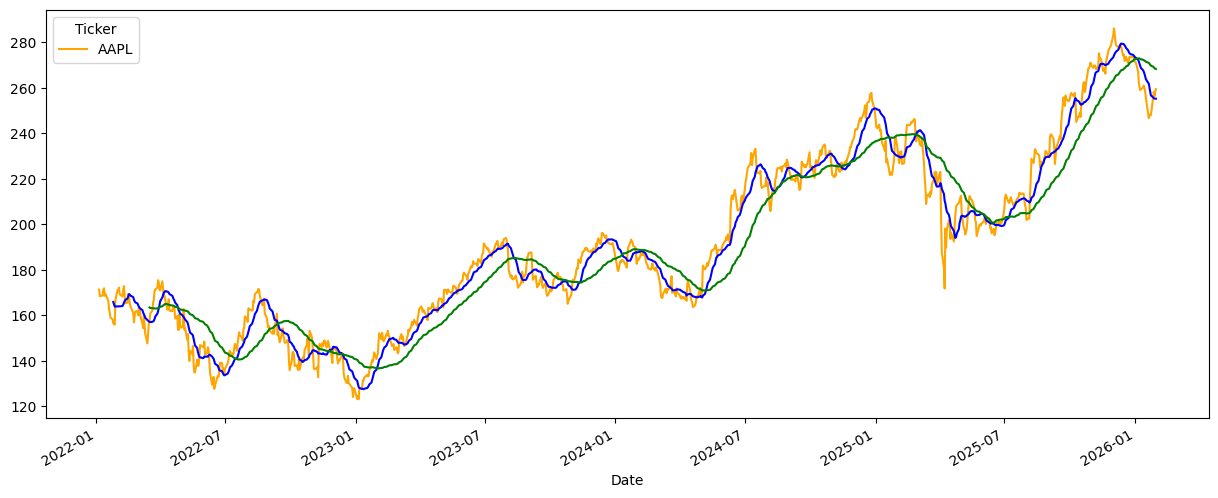

In [22]:
df_aapl['SMA'] = df_aapl['Close'].rolling(window=14).mean()
df_aapl['SMA50'] = df_aapl['Close'].rolling(window=50).mean()
df_aapl['Close'].plot(figsize=(15,6), color="orange")
df_aapl['SMA'].plot(figsize=(15,6), color="blue")
df_aapl['SMA50'].plot(figsize=(15, 6), color='green')
plt.show()

In [23]:
df_aapl['change'] = (((df_aapl['Close'] - df_aapl['Open'])) / (df_aapl['Open']) * 100)
df_fb['change'] = (((df_fb['Close'] - df_fb['Open'])) / (df_fb['Open']) * 100)
df_gold['change'] = (((df_gold['Close'] - df_gold['Open'])) / (df_gold['Open']) * 100)

df_aapl.tail(5).round(2)

Price,Close,High,Low,Open,Volume,SMA,SMA50,change
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2026-01-26,255.41,256.56,249.80,251.48,55969200,255.87,269.37,1.56
2026-01-27,258.27,261.95,258.21,259.17,49648300,255.58,269.07,-0.35
2026-01-28,256.44,258.86,254.51,257.65,41288000,255.30,268.74,-0.47
2026-01-29,258.28,259.65,254.41,258.00,67253000,255.25,268.45,0.11
2026-01-30,259.48,261.90,252.18,255.17,92352600,255.26,268.30,1.69


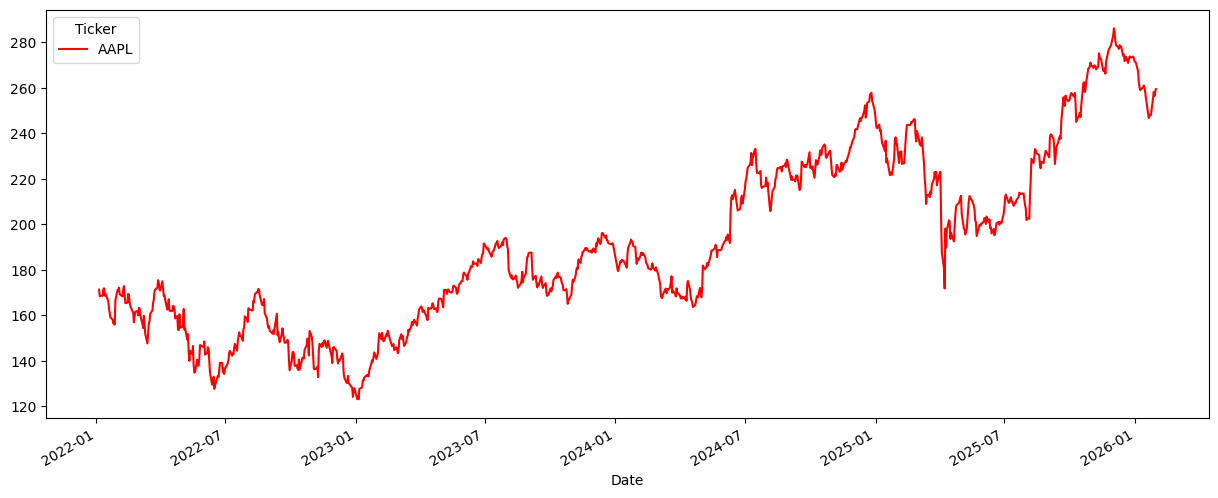

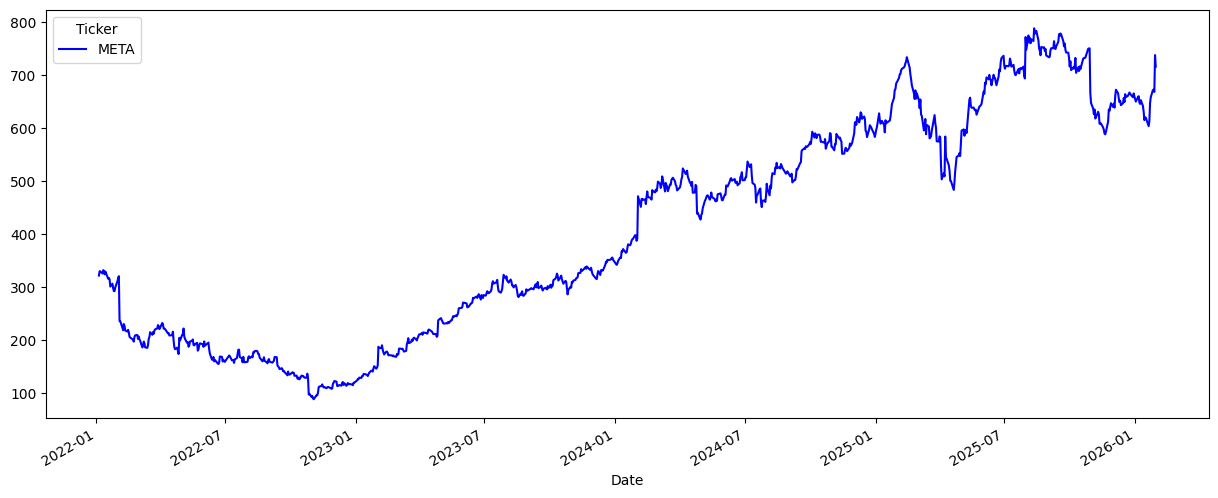

In [24]:
df_aapl['Close'].plot(figsize=(15,6), color="red")
df_fb['Close'].plot(figsize=(15,6), color="blue")
plt.show()

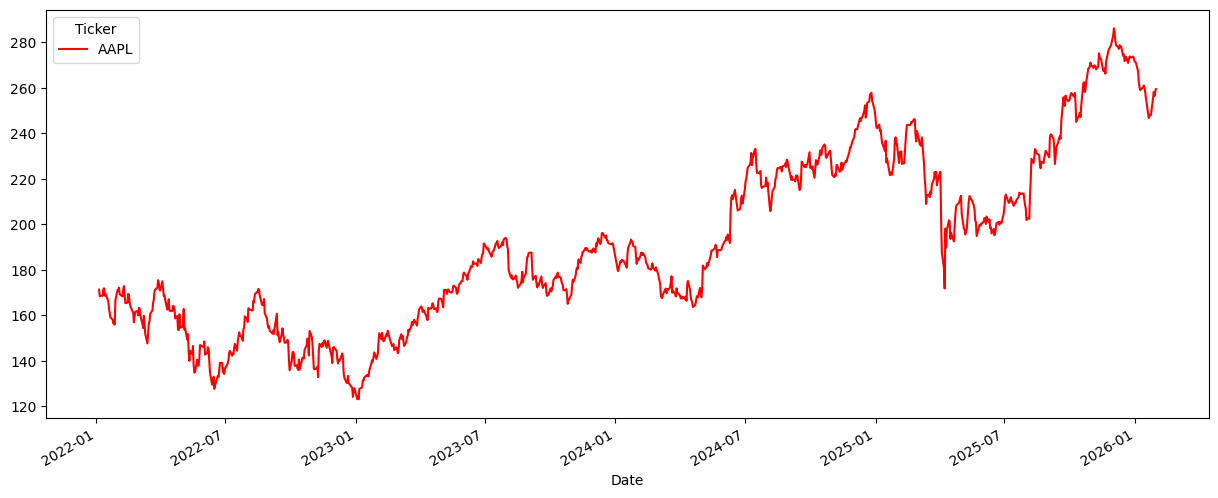

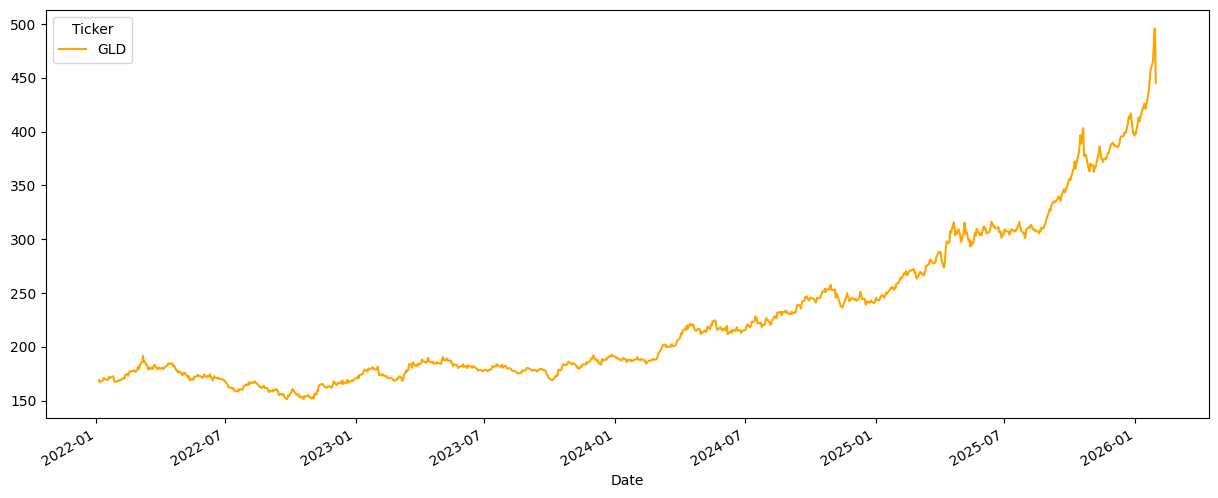

In [25]:
df_aapl['Close'].plot(figsize=(15,6), color="red")
df_gold['Close'].plot(figsize=(15,6), color="orange")
plt.show()

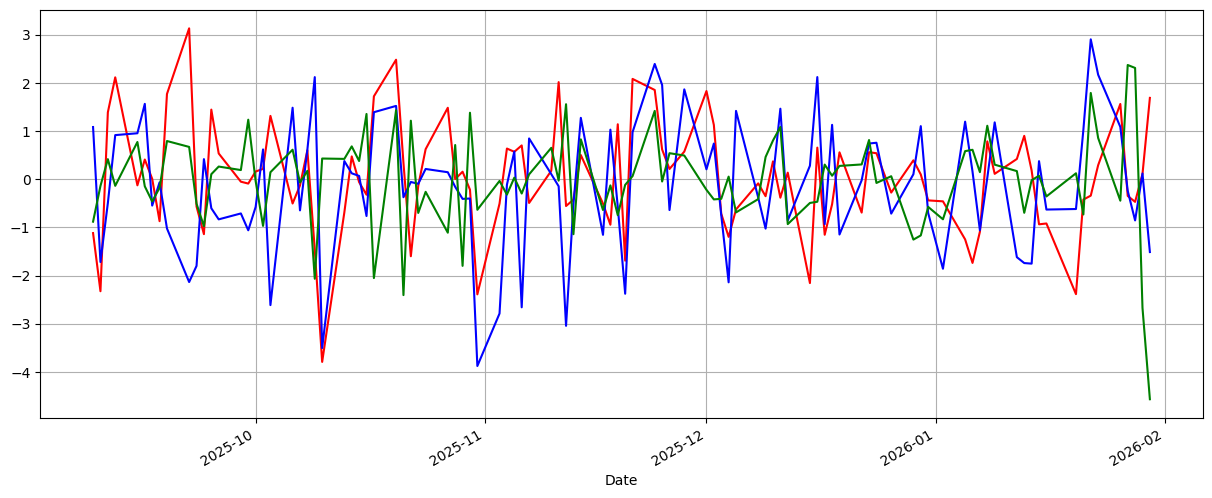

In [26]:
df_aapl['change'].tail(100).plot(grid=True, figsize=(15,6), color="red")
df_fb['change'].tail(100).plot(grid=True, figsize=(15,6), color="blue")
df_gold['change'].tail(100).plot(grid=True, figsize=(15,6), color="green")
plt.show()

In [27]:
df_aapl['label'] = df_aapl['Close'].shift(-30)
df_aapl.tail(35)

Price,Close,High,Low,Open,Volume,SMA,SMA50,change,label
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,
Date,,,,,,,,,
2025-12-10,278.779999,279.750000,276.440002,277.750000,33038300,278.128573,266.839431,0.370837,255.410004
2025-12-11,278.029999,279.589996,273.809998,279.100006,33248000,278.970001,267.295979,-0.383378,258.269989
2025-12-12,278.279999,279.220001,276.820007,277.899994,39532900,279.455002,267.723959,0.136742,256.440002
2025-12-15,274.109985,280.149994,272.839996,280.149994,50409100,279.325714,268.050757,-2.155991,258.279999
2025-12-16,274.609985,275.500000,271.790009,272.820007,37648600,279.157142,268.414128,0.656102,259.480011
2025-12-17,271.839996,276.160004,271.640015,275.010010,50138700,278.749285,268.726296,-1.152690,NaN
2025-12-18,272.190002,273.630005,266.950012,273.609985,51630700,278.273570,269.013894,-0.518981,NaN
2025-12-19,273.670013,274.600006,269.899994,272.149994,144632000,277.600000,269.411415,0.558523,NaN


In [28]:
X = np.array(df_aapl.drop(['label', 'SMA'], axis=1))
X = sklearn.preprocessing.scale(X)

In [29]:
predict_data = X[-30:]

In [30]:
X = X[:30]

In [31]:
y = np.array(df_aapl['label'])
y = y[:-30]

In [32]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size = 0.2)
model = sklearn.linear_model.LinearRegression()
model.fit(X_train,y_train)
accuracy = model.score(X_test, y_test)
accuracy

ValueError: Found input variables with inconsistent numbers of samples: [30, 991]

In [42]:
predicted_data = model.predict(predict_data)
predicted_data

NameError: name 'model' is not defined

In [43]:
df_aapl['predict']= np.nan
df_aapl.tail(35)

Price,Close,High,Low,Open,Volume,SMA,SMA50,change,label,predict
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
Date,,,,,,,,,,
2025-12-10,278.779999,279.750000,276.440002,277.750000,33038300,278.128573,266.839431,0.370837,255.410004,NaN
2025-12-11,278.029999,279.589996,273.809998,279.100006,33248000,278.970001,267.295979,-0.383378,258.269989,NaN
2025-12-12,278.279999,279.220001,276.820007,277.899994,39532900,279.455002,267.723959,0.136742,256.440002,NaN
2025-12-15,274.109985,280.149994,272.839996,280.149994,50409100,279.325714,268.050757,-2.155991,258.279999,NaN
2025-12-16,274.609985,275.500000,271.790009,272.820007,37648600,279.157142,268.414128,0.656102,259.480011,NaN
2025-12-17,271.839996,276.160004,271.640015,275.010010,50138700,278.749285,268.726296,-1.152690,NaN,NaN
2025-12-18,272.190002,273.630005,266.950012,273.609985,51630700,278.273570,269.013894,-0.518981,NaN,NaN
2025-12-19,273.670013,274.600006,269.899994,272.149994,144632000,277.600000,269.411415,0.558523,NaN,NaN


In [44]:
last_date = df_aapl.iloc[-1].name

In [45]:
one_day = 86400
next_unix = last_date.timestamp() + one_day


In [46]:
for data in predicted_data:
    next_date = datetime.fromtimestamp(next_unix)
    next_unix += one_day
    df_aapl.loc[next_date] = np.append([np.nan]* (len(df_aapl.columns)-1), data)

NameError: name 'predicted_data' is not defined

KeyError: 'Predict'

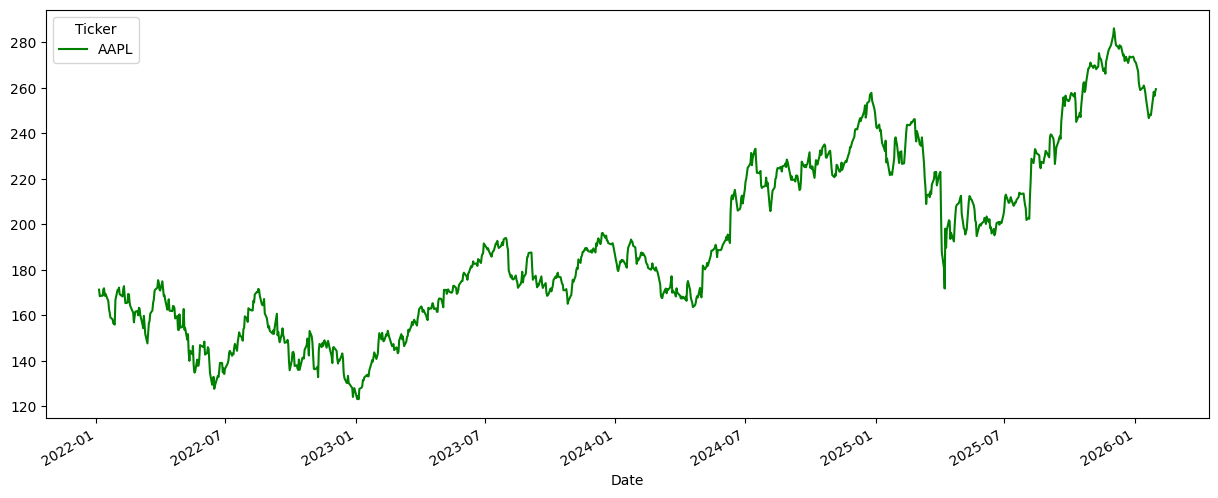

In [50]:
df_aapl['Close'].plot(figsize=(15,6), color="green")
df_aapl['Predict'].plot(figsize=(15,6), color="orange")
plt.show()